In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from unidecode import unidecode
import unicodedata
import re

In [2]:
merged_df = pd.read_csv("merged_drug_data(3).csv", encoding='utf-8-sig')
print(merged_df.shape)
print(merged_df.columns)
merged_df.info()
merged_df.head()

(21408, 17)
Index(['drug_name', 'active_ingredient', 'dosage_form', 'strength', 'packing',
       'indication', 'usage', 'side_effect', 'contraindication', 'caution',
       'manufacturer', 'category', 'price', 'unit', 'url', 'image_url',
       'source'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21408 entries, 0 to 21407
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   drug_name          21408 non-null  object 
 1   active_ingredient  15017 non-null  object 
 2   dosage_form        15384 non-null  object 
 3   strength           0 non-null      float64
 4   packing            11428 non-null  object 
 5   indication         20467 non-null  object 
 6   usage              9523 non-null   object 
 7   side_effect        16276 non-null  object 
 8   contraindication   16817 non-null  object 
 9   caution            16865 non-null  object 
 10  manufacturer       13160 non-nu

,drug_name,active_ingredient,dosage_form,strength,packing,indication,usage,side_effect,contraindication,caution,manufacturer,category,price,unit,url,image_url,source
0,"Buscopan 10mg trị co thắt đường tiêu hoá, sinh...",Hyoscin butylbromid,Viên nén bao đường,NaN,NaN,"Co thắt đường tiêu hóa, co thắt và rối loạn vậ...",Nên dùng theo liều khuyến cáo như sau trừ khi ...,Nhiều tác dụng ngoại ý được liệt kê dưới đây l...,BUSCOPAN chống chỉ định khi: - Bệnh nhân đã bi...,- Thận trọng khi sử dụng Trong các trường hợp ...,Sanofi,"Tiêu hóa, gan mật",1500.0,NaN,https://www.nhathuocankhang.com/thuoc-tri-viem...,https://cdn.tgdd.vn/Products/Images/10039/1535...,ankhang
1,Spamerin 135mg trị các triệu chứng của hội chứ...,Mebeverin hydroclorid,Viên nén bao phim,NaN,NaN,Mebeverin được dùng trong điều trị các triệu c...,Người lớn và trẻ em trên 18 tuổi: 1 viên x 3 l...,"Rất hiếm: Rối loạn tiêu hóa, chóng mặt, nhức đ...",Quá mẫn cảm với mebeverin hydroclorid hay với ...,- Thận trọng khi sử dụng Tránh dùng thuốc ở bệ...,Abbott,"Tiêu hóa, gan mật",23000.0,NaN,https://www.nhathuocankhang.com/thuoc-tri-benh...,https://cdn.tgdd.vn/Products/Images/10041/2433...,ankhang
2,"Silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ...",Silymarin,Viên nén bao đường,NaN,NaN,Hỗ trợ điều trị các bệnh về gan: Viêm gan do v...,- Người lớn: 2 viên/lần x 2 - 3 lần/ngày. - Qu...,Với liều thông thường rất hiếm gặp tác dụng kh...,Mẫn cảm với bất kỳ thành phần nào của thuốc. T...,- Thận trọng khi sử dụng Không dùng quá liều c...,Mediplantex,"Tiêu hóa, gan mật",99000.0,NaN,https://www.nhathuocankhang.com/thuoc-tri-gan-...,https://cdn.tgdd.vn/Products/Images/10040/3123...,ankhang
3,Viên nhai Kremil-S làm dịu các triệu chứng đầy...,"Nhôm hydroxyd, Magnesi hydroxyd, Simethicon",Viên nén nhai,NaN,NaN,Làm dịu các triệu chứng tăng tiết acid dạ dày ...,Liều dùng cho người lớn: dùng 1 - 2 viên sau m...,"Buồn nôn, nôn, miệng có vị kim loại, tiêu chảy...",Mẫn cảm với bất cứ thành phần nào của thuốc. S...,- Thận trọng khi sử dụng Bệnh nhân có suy tim ...,United International Pharma,"Tiêu hóa, gan mật",1200.0,NaN,https://www.nhathuocankhang.com/thuoc-tri-viem...,https://cdn.tgdd.vn/Products/Images/10039/1313...,ankhang
4,"Đại Tràng Nhất Nhất trị viêm đại tràng, rối lo...","Xa tiền tử, Ngũ bội tử, Cam thảo, Bạch truật, ...",Viên nén bao phim,NaN,NaN,"Trị viêm đại tràng, tiêu chảy, rối loạn tiêu h...",Nên uống vào lúc đói. Trẻ em 3-15 tuổi: Ngày u...,Chưa ghi nhận được báo cáo về phản ứng có hại ...,"Trẻ em dưới 30 tháng tuổi, trẻ em có tiền sử đ...",- Thận trọng khi sử dụng Thận trọng khi sử dụn...,Nhất Nhất,"Tiêu hóa, gan mật",125000.0,NaN,https://www.nhathuocankhang.com/thuoc-tri-benh...,https://cdn.tgdd.vn/Products/Images/10041/2189...,ankhang


In [3]:
# Loại bỏ cột rỗng
merged_df = merged_df.dropna(axis=1, how="all")
print(merged_df.shape)
merged_df.info()

(21408, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21408 entries, 0 to 21407
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   drug_name          21408 non-null  object 
 1   active_ingredient  15017 non-null  object 
 2   dosage_form        15384 non-null  object 
 3   packing            11428 non-null  object 
 4   indication         20467 non-null  object 
 5   usage              9523 non-null   object 
 6   side_effect        16276 non-null  object 
 7   contraindication   16817 non-null  object 
 8   caution            16865 non-null  object 
 9   manufacturer       13160 non-null  object 
 10  category           21408 non-null  object 
 11  price              2722 non-null   float64
 12  url                21408 non-null  object 
 13  image_url          11165 non-null  object 
 14  source             21408 non-null  object 
dtypes: float64(1), object(14)
memory usage: 2.5+ MB


Số lượng thuốc theo nguồn:
source
minhchau      9211
longchau      5670
pharmacity    3551
ankhang       1968
dieutri       1008
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_37976\3302223725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'minhchau'),
  Text(1, 0, 'longchau'),
  Text(2, 0, 'pharmacity'),
  Text(3, 0, 'ankhang'),
  Text(4, 0, 'dieutri')])

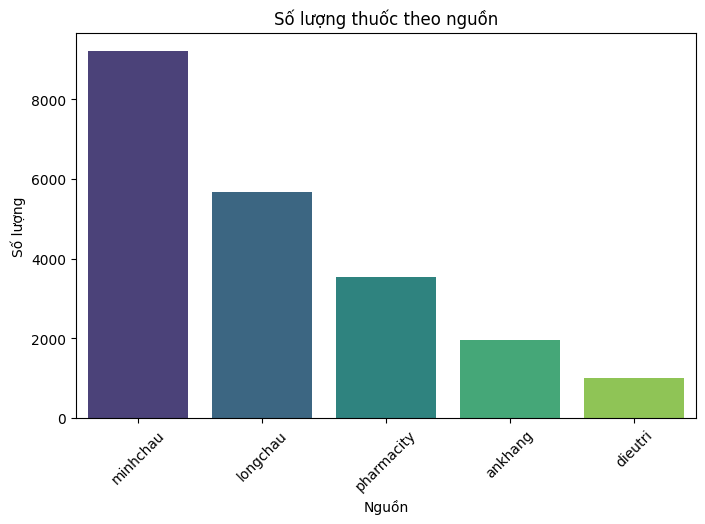

In [4]:
# Thống kê số lượng thuốc theo nguồn
source_counts = merged_df['source'].value_counts()
print("Số lượng thuốc theo nguồn:")
print(source_counts)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')
plt.title("Số lượng thuốc theo nguồn")
plt.xlabel("Nguồn")
plt.ylabel("Số lượng")
plt.xticks(rotation=45)

Tổng số lượng category khác nhau:
107
Số lượng thuốc theo category:
category
Thuốc kháng sinh, Kháng nấm                        1103
Thuốc tim mạch & Huyết áp                          1083
Thuốc tim mạch & máu                                958
Thuốc dùng ngoài                                    900
Thuốc hướng thần & Cai nghiện                       891
                                                   ... 
Dung dịch vệ sinh phụ nữ                              2
Dầu xoa bóp, dầu gió                                  1
Xịt mũi                                               1
Sản phẩm trị mụn                                      1
Thuốc hướng thần & Cai nghiện | Thuốc giãn mạch       1
Name: count, Length: 107, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_37976\213469502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.head(20).index, y=category_counts.head(20).values, palette='viridis')


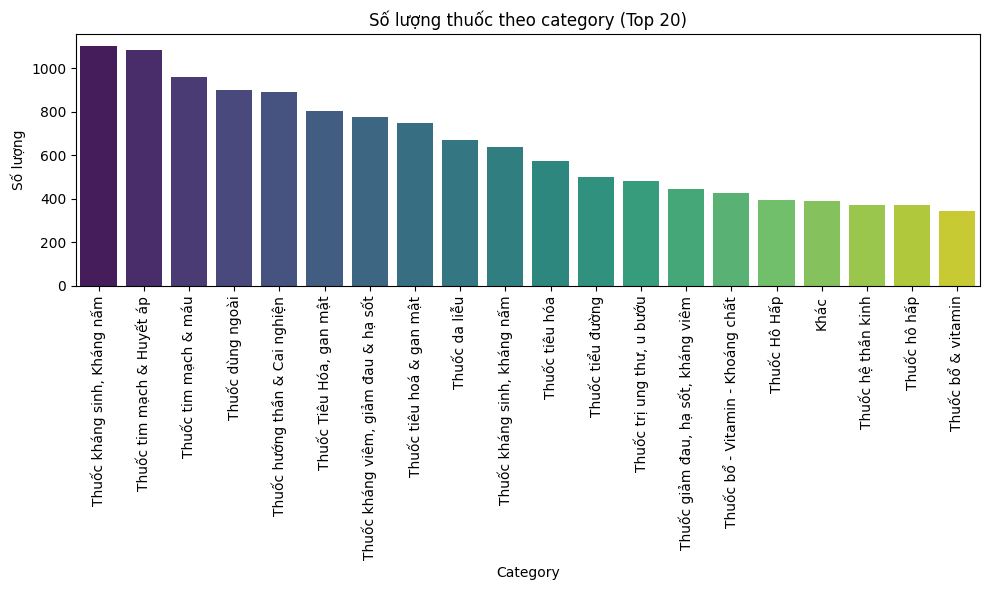

In [5]:
# Thống kê số lượng thuốc theo category
print("Tổng số lượng category khác nhau:")
print(merged_df['category'].nunique())
category_counts = merged_df['category'].value_counts()  
print("Số lượng thuốc theo category:")
print(category_counts)



# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.head(20).index, y=category_counts.head(20).values, palette='viridis')
plt.title("Số lượng thuốc theo category (Top 20)")
plt.xlabel("Category")
plt.ylabel("Số lượng")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
# In toàn bộ category 
print("Danh sách category:")
print(merged_df['category'].dropna().unique())


Danh sách category:
['Tiêu hóa, gan mật' 'Tiết niệu, sinh dục' 'Thần kinh, não bộ'
 'Mắt, tai mũi họng' 'Kháng sinh, kháng nấm' 'Hô hấp'
 'Giảm đau, hạ sốt, kháng viêm' 'Dầu, Cao Xoa, Miếng Dán'
 'Da liễu, dị ứng' 'Cơ xương khớp, gút' 'Thuốc bổ và vitamin'
 'Thuốc giãn mạch' 'Thuốc Hô Hấp' 'Thuốc trị ung thư, u bướu'
 'Thuốc tim mạch & Huyết áp' 'Thuốc đường tiết niệu' 'Thuốc kháng Virus'
 'Thuốc Hocmon, Nội tiết tố' 'Thuốc hướng thần & Cai nghiện'
 'Thuốc kháng sinh, Kháng nấm' 'Thuốc tiểu đường' 'Thuốc dùng ngoài'
 'Thuốc gout, cơ, xương khớp' 'Thuốc gây mê, gây tê'
 'Thuốc chống dị ứng ( kháng histamin)' 'Thuốc Tiêu Hóa, gan mật'
 'Thuốc kháng viêm, giảm đau & hạ sốt' 'Thuốc bổ - Vitamin - Khoáng chất'
 'Thuốc cấp cứu và giải độc' 'Thuốc cường dương' 'Thuốc da liễu'
 'Thuốc tác dụng đối với máu' 'Thuốc mọc tóc' 'Thuốc cầm máu'
 'Thuốc tiêm, dịch truyền' 'Thuốc trị viêm gan B,C & HIV'
 'Thuốc ngừa thai' 'Thuốc điều hòa miễn dịch' 'Thuốc phụ khoa' 'Thuốc trĩ'
 'Thuốc chống thải ghép' 

In [7]:
# Danh sách category từ từng nguồn
sources = merged_df['source'].dropna().unique()
for source in sources:
    source_categories = merged_df[merged_df['source'] == source]['category'].dropna().unique()
    print(f"Category từ nguồn {source}:")
    print(source_categories)
    print("\n")

# Số lượng category theo từng nguồn
source_category_counts = merged_df.groupby('source')['category'].nunique()
print("Số lượng category theo từng nguồn:")
print(source_category_counts)
print("Tổng số category từ tất cả nguồn:", source_category_counts.sum())


Category từ nguồn ankhang:
['Tiêu hóa, gan mật' 'Tiết niệu, sinh dục' 'Thần kinh, não bộ'
 'Mắt, tai mũi họng' 'Kháng sinh, kháng nấm' 'Hô hấp'
 'Giảm đau, hạ sốt, kháng viêm' 'Dầu, Cao Xoa, Miếng Dán'
 'Da liễu, dị ứng' 'Cơ xương khớp, gút' 'Thuốc bổ và vitamin'
 'Tim mạch, tiểu đường, mỡ máu']


Category từ nguồn minhchau:
['Thuốc giãn mạch' 'Thuốc Hô Hấp' 'Thuốc trị ung thư, u bướu'
 'Thuốc tim mạch & Huyết áp' 'Thuốc đường tiết niệu' 'Thuốc kháng Virus'
 'Thuốc Hocmon, Nội tiết tố' 'Thuốc hướng thần & Cai nghiện'
 'Thuốc kháng sinh, Kháng nấm' 'Thuốc tiểu đường' 'Thuốc dùng ngoài'
 'Thuốc gout, cơ, xương khớp' 'Thuốc gây mê, gây tê'
 'Thuốc chống dị ứng ( kháng histamin)' 'Thuốc Tiêu Hóa, gan mật'
 'Thuốc kháng viêm, giảm đau & hạ sốt' 'Thuốc bổ - Vitamin - Khoáng chất'
 'Thuốc cấp cứu và giải độc' 'Thuốc cường dương' 'Thuốc da liễu'
 'Thuốc tác dụng đối với máu' 'Thuốc mọc tóc' 'Thuốc cầm máu'
 'Thuốc tiêm, dịch truyền' 'Thuốc trị viêm gan B,C & HIV'
 'Thuốc ngừa thai' 'Thuốc điều

In [ ]:

from rapidfuzz import process, fuzz

main_categories = [
    "Da liễu & dị ứng",
    "Tiêu hóa & gan mật",
    "Hô hấp",
    "Tim mạch & huyết áp",
    "Thần kinh & Não bộ",
    "Cơ xương khớp",
    "Giảm đau & Hạ sốt",
    "Kháng sinh & Kháng viêm",
    "Tiết niệu & Sinh dục",
    "Tai, mắt, mũi, họng",
    "Vitamin & Khoáng chất",
    "Tiểu đường",
    "Phụ nữ & Sản phụ khoa",
    "Nam giới",
    "Ung thư",
    "Khác",
]

# Keyword map mới: tránh dùng token quá chung như "mau", "ho", "mat", "mui", "hong", "thuoc tri"
keyword_map = {
    "Da liễu & dị ứng": [
        r"\bda lieu\b", r"\bviem da\b", r"\beczema\b", r"\bvay nen\b", r"\bnam da\b",
        r"\bviem da co dia\b", r"\bviem da tiep xuc\b", r"\bviem da tiet ba\b",
        r"\bviem nang long\b", r"\bmun\b", r"\bmun trung ca\b", r"\bmun viem\b",
        r"\bmun boc\b", r"\bmun mu\b", r"\btroc vay\b", r"\bkho da\b",
        r"\bgel boi da\b", r"\bkem boi da\b", r"\bseo\b", r"\bsan pham tri mun\b",
        r"\bthuoc da lieu\b", r"\bdi ung\b", r"\bme day\b", r"\bngua\b",
        r"\bngua da\b", r"\bphat ban\b", r"\bban do\b", r"\bnoi man do\b",
        r"\bkich ung\b", r"\bkhang histamin\b", r"\bthuoc di ung\b",
        r"\bkhang di ung\b", r"\bdi ung mien dich\b"
    ],

    "Tiêu hóa & gan mật": [
        r"\btieu hoa\b", r"\btieu hoa gan mat\b", r"\bgan mat\b", r"\bda day\b",
        r"\btrao nguoc\b", r"\bviem loet da day\b", r"\btieu chay\b", r"\btao bon\b",
        r"\bhoi chung ruot kich thich\b", r"\bviem dai trang\b", r"\bday hoi\b",
        r"\bo chua\b", r"\bkho tieu\b", r"\bbuon non\b", r"\bnon\b",
        r"\bdau thuong vi\b", r"\btruong bung\b", r"\bsoi mat\b", r"\bviem gan\b",
        r"\bgan nhiem mo\b", r"\btui mat\b", r"\btri noi\b", r"\btri ngoai\b",
        r"\bnut ke hau mon\b", r"\bthuoc tri\b"
    ],

    "Hô hấp": [
        r"\bho hap\b", r"\bhen phe quan\b", r"\bviem phe quan\b", r"\bviem phoi\b",
        r"\bcopd\b", r"\bco that phe quan\b", r"\bho\b", r"\bho khan\b",
        r"\bho co dom\b", r"\bho lau ngay\b", r"\bho dem\b", r"\bkho tho\b",
        r"\bkho khe\b", r"\btho rit\b", r"\btuc nguc\b", r"\bdom\b", r"\bco dom\b",
        r"\bviem duong ho hap\b", r"\bcam lanh\b", r"\bcam cum\b", r"\bsot mui\b",
        r"\bviem phe tieu phe quan\b", r"\bthuoc ho hap\b", r"\bthuoc cam lanh\b"
    ],

    "Tim mạch & huyết áp": [
        r"\btim mach\b", r"\bhuyet ap\b", r"\btang huyet ap\b", r"\bha huyet ap\b",
        r"\bsuy tim\b", r"\broi loan nhip tim\b", r"\bdau that nguc\b", r"\bmach vanh\b",
        r"\broi loan lipid\b", r"\bmo mau\b", r"\bcholesterol\b", r"\bthieu mau co tim\b",
        r"\bthuoc gian mach\b", r"\bgian mach\b", r"\bchong dong\b",
        r"\bchong ket tap tieu cau\b", r"\bthieu mau nao\b", r"\btuan hoan nao\b",
        r"\btuan hoan mau nao\b", r"\bthuoc tim mach\b", r"\bthuoc tac dung doi voi mau\b",
        r"\bdanh trong nguc\b", r"\bhoi hop\b", r"\bphu chan\b"
    ],

    "Thần kinh & Não bộ": [
        r"\bthan kinh\b", r"\bnao bo\b", r"\bdong kinh\b", r"\bparkinson\b",
        r"\balzheimer\b", r"\bdau nua dau\b", r"\broi loan tien dinh\b",
        r"\btram cam\b", r"\blo au\b", r"\bmat ngu\b", r"\bchong mat\b",
        r"\bstress\b", r"\bcang thang\b", r"\ban than\b", r"\bhuong than\b",
        r"\bcai nghien\b", r"\bchong say xe\b", r"\bte tay chan\b", r"\brun tay\b",
        r"\bsuy giam tri nho\b", r"\bmat thang bang\b", r"\bthuoc than kinh\b"
    ],

    "Cơ xương khớp": [
        r"\bco xuong khop\b", r"\bthoai hoa khop\b", r"\bviem khop\b", r"\bgout\b",
        r"\bdau khop\b", r"\bdau lung\b", r"\bdau cot song\b", r"\bco cung co\b",
        r"\bbong gan\b", r"\bchuot rut\b", r"\bdau vai gay\b", r"\bdau moi vai gay\b",
        r"\bthoat vi dia dem\b", r"\bdau than kinh toa\b", r"\bsung khop\b",
        r"\bcung khop\b", r"\bnhuc xuong khop\b", r"\bdau cao xoa\b", r"\bcao xoa\b",
        r"\bmieng dan\b", r"\bdau gio\b", r"\bte boi\b", r"\bthuoc te boi\b",
        r"\bdau xoa bop dau gio\b", r"\bdau cao xoa bop\b"
    ],

    "Giảm đau & Hạ sốt": [
        r"\bgiam dau\b", r"\bha sot\b", r"\bdau nhuc\b", r"\bsot\b", r"\bsot cao\b",
        r"\bdau cap tinh\b", r"\bdau dau\b", r"\bdau rang\b", r"\bdau bung kinh\b",
        r"\bdau sau phau thuat\b", r"\bdau sau chan thuong\b", r"\bnhuc moi\b",
        r"\bdau nhuc co the\b", r"\bdau tai\b", r"\bdau hong\b", r"\bha nhiet\b",
        r"\bthuoc giam dau ha sot\b", r"\bgiam dau ha sot\b"
    ],

    "Kháng sinh & Kháng viêm": [
        r"\bkhang sinh\b", r"\bkhang viem\b", r"\bkhang nam\b", r"\bkhang virus\b",
        r"\bnhiem khuan\b", r"\bvi khuan\b", r"\bnhiem trung\b", r"\bviem nhiem\b",
        r"\bboi nhiem\b", r"\bap xe\b", r"\bviem mu\b", r"\bvet thuong nhiem trung\b",
        r"\bsung viem\b", r"\bchay mu\b", r"\bthuoc khang sinh\b",
        r"\bthuoc khang virus\b", r"\bthuoc khang viem\b", r"\bdieu hoa mien dich\b",
        r"\bthuoc dieu hoa mien dich\b", r"\buc che mien dich\b"
    ],

    "Tiết niệu & Sinh dục": [
        r"\btiet nieu\b", r"\bviem tiet nieu\b", r"\bviem bang quang\b",
        r"\bduong tiet nieu\b", r"\bsoi than\b", r"\bnhiem trung tiet nieu\b",
        r"\btieu buot\b", r"\btieu rat\b", r"\btieu nhieu lan\b", r"\btieu dem\b",
        r"\btieu kho\b", r"\btieu khong het\b", r"\bnuoc tieu duc\b",
        r"\bsinh duc\b", r"\bviem tuyen tien liet\b", r"\bphu dai tien liet tuyen\b",
        r"\bthuoc tiet nieu\b", r"\bthuoc duong tiet nieu\b"
    ],

    "Tai, mắt, mũi, họng": [
        r"\bviem mui di ung\b", r"\bviem xoang\b", r"\bviem hong\b", r"\bviem amidan\b",
        r"\bviem mui hong\b", r"\bnghet mui\b", r"\bso mui\b", r"\bhat hoi\b",
        r"\bdau hong\b", r"\brat hong\b", r"\bngua hong\b", r"\bkhan tieng\b",
        r"\bnuot dau\b", r"\bviem ket mac\b", r"\bdo mat\b", r"\bngua mat\b",
        r"\bcom mat\b", r"\bchay nuoc mat\b", r"\bviem tai giua\b", r"\bviem tai ngoai\b",
        r"\bu tai\b", r"\bnghe kem\b", r"\bdau tai\b", r"\bnho mat\b",
        r"\bnho tai\b", r"\bxit mui\b", r"\bthuoc mat tai mui hong\b",
        r"\bthuoc mat tai mui\b"
    ],

    "Vitamin & Khoáng chất": [
        r"\bvitamin\b", r"\bkhoang chat\b", r"\bvitamin c\b", r"\bvitamin d\b",
        r"\bvitamin b\b", r"\bcanxi\b", r"\bsat\b", r"\bkem\b", r"\bmagie\b",
        r"\bdha\b", r"\bomega\s*3\b", r"\bbo sung\b", r"\bthuoc bo\b",
        r"\bmultivitamin\b", r"\bda vitamin\b", r"\bvi chat\b",
        r"\bsuy nhuoc\b", r"\bthuoc bo vitamin\b", r"\bvitamin khoang chat\b"
    ],

    "Tiểu đường": [
        r"\btieu duong\b", r"\bdai thao duong\b", r"\bduong huyet\b", r"\bhba1c\b",
        r"\btang duong huyet\b", r"\bha duong huyet\b", r"\bkhang insulin\b",
        r"\bthuoc tieu duong\b", r"\bthuoc tri tieu duong\b"
    ],

    "Phụ nữ & Sản phụ khoa": [
        r"\bphu nu\b", r"\bsan phu khoa\b", r"\bphu khoa\b", r"\bkinh nguyet\b",
        r"\bviem am dao\b", r"\btranh thai\b", r"\bthai ky\b", r"\bsau sinh\b",
        r"\btien man kinh\b", r"\broi loan kinh nguyet\b", r"\bcham kinh\b",
        r"\brong kinh\b", r"\bkhi hu\b", r"\bngua am dao\b", r"\bnoi tiet\b",
        r"\bhocmon\b", r"\bnoi tiet to\b", r"\bdung dich ve sinh phu nu\b",
        r"\bthuoc phu khoa\b", r"\bthuoc danh cho phu nu\b", r"\bthuoc danh cho nu\b"
    ],

    "Nam giới": [
        r"\bnam gioi\b", r"\byeu sinh ly nam\b", r"\broi loan cuong duong\b",
        r"\bxuat tinh som\b", r"\btang cuong sinh ly nam\b", r"\bgiam ham muon\b",
        r"\bcuong duong\b", r"\bsinh ly nam\b", r"\bthuoc cuong duong\b",
        r"\bthuoc danh cho nam\b", r"\bthuoc cho nam gioi\b"
    ],

    "Ung thư": [
        r"\bung thu\b", r"\bu ac tinh\b", r"\bcarcinoma\b", r"\bhoa tri\b",
        r"\bxa tri\b", r"\bkhoi u\b", r"\bdi can\b", r"\bbuou\b",
        r"\bthuoc ung thu\b", r"\bthuoc tri ung thu u buou\b", r"\bchong thai ghep\b"
    ],
}

In [9]:
# map_category mới: ưu tiên manual map theo category gốc, rồi exact/fallback
fuzzy_threshold = 75
main_categories_norm = {c: unidecode(c).lower() for c in main_categories}

category_priority = [
    "Tiểu đường",
    "Ung thư",
    "Tiết niệu & Sinh dục",
    "Phụ nữ & Sản phụ khoa",
    "Nam giới",
    "Tim mạch & huyết áp",
    "Thần kinh & Não bộ",
    "Tiêu hóa & gan mật",
    "Hô hấp",
    "Tai, mắt, mũi, họng",
    "Da liễu & dị ứng",
    "Cơ xương khớp",
    "Giảm đau & Hạ sốt",
    "Kháng sinh & Kháng viêm",
    "Vitamin & Khoáng chất",
    "Khác",
]
_priority_rank = {c: i for i, c in enumerate(category_priority)}

def normalize_for_match(x: str):
    if pd.isna(x):
        return ""
    t = unidecode(str(x)).lower()
    t = re.sub(r"[^a-z0-9\s/&,-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# Map tay theo category gốc: đây là phần quan trọng nhất
# Map tay theo category gốc: phải khớp đúng taxonomy hiện tại
manual_category_map = {
    # Tieu hoa
    "tieu hoa gan mat": "Tiêu hóa & gan mật",
    "thuoc tieu hoa gan mat": "Tiêu hóa & gan mật",
    "thuoc tieu hoa": "Tiêu hóa & gan mật",
    "tieu hoa": "Tiêu hóa & gan mật",
    "thuoc tri": "Tiêu hóa & gan mật",

    # Ho hap
    "ho hap": "Hô hấp",
    "thuoc ho hap": "Hô hấp",
    "he ho hap": "Hô hấp",
    "thuoc cam lanh": "Hô hấp",
    "thuoc cam lanh ho": "Hô hấp",

    # Tai mat mui hong
    "mat tai mui hong": "Tai, mắt, mũi, họng",
    "thuoc mattai mui": "Tai, mắt, mũi, họng",
    "thuoc mat tai mui": "Tai, mắt, mũi, họng",
    "thuoc mat tai mui hong": "Tai, mắt, mũi, họng",
    "mattai mui hong": "Tai, mắt, mũi, họng",
    "xit mui": "Tai, mắt, mũi, họng",
    "thuoc nho mat": "Tai, mắt, mũi, họng",
    "thuoc mattaimui": "Tai, mắt, mũi, họng",
    "thuoc mat/tai/mui": "Tai, mắt, mũi, họng",
    "thuoc mat tai mui hong": "Tai, mắt, mũi, họng",
    "mattaimuihong": "Tai, mắt, mũi, họng",
    "thuoc nho tai": "Tai, mắt, mũi, họng",

    # Da lieu di ung
    "da lieu": "Da liễu & dị ứng",
    "thuoc da lieu": "Da liễu & dị ứng",
    "san pham tri mun": "Da liễu & dị ứng",
    "thuoc dung ngoai": "Da liễu & dị ứng",
    "da lieu di ung": "Da liễu & dị ứng",
    "thuoc di ung": "Da liễu & dị ứng",
    "khang di ung": "Da liễu & dị ứng",
    "thuoc khang di ung": "Da liễu & dị ứng",
    "thuoc chong di ung khang histamin": "Da liễu & dị ứng",
    "di ung mien dich": "Da liễu & dị ứng",

    # Tim mach
    "thuoc tim mach huyet ap": "Tim mạch & huyết áp",
    "thuoc tim mach mau": "Tim mạch & huyết áp",
    "tim mach": "Tim mạch & huyết áp",
    "mau": "Tim mạch & huyết áp",
    "thuoc tac dung doi voi mau": "Tim mạch & huyết áp",
    "thuoc gian mach": "Tim mạch & huyết áp",
    "tim mach tieu duong mo mau": "Tim mạch & huyết áp",

    # Than kinh
    "than kinh nao bo": "Thần kinh & Não bộ",
    "thuoc than kinh": "Thần kinh & Não bộ",
    "thuoc he than kinh": "Thần kinh & Não bộ",
    "than kinh tam than": "Thần kinh & Não bộ",
    "thuoc huong than cai nghien": "Thần kinh & Não bộ",
    "thuoc huong than cai nghien thuoc gian mach": "Thần kinh & Não bộ",
    "thuoc chong say xe": "Thần kinh & Não bộ",
    "thuoc giai doc khu doc va ho tro cai nghien": "Thần kinh & Não bộ",
    "thuoc huong than cai nghien | thuoc gian mach": "Thần kinh & Não bộ",

    # Co xuong khop
    "co xuong khop gut": "Cơ xương khớp",
    "thuoc gout co xuong khop": "Cơ xương khớp",
    "thuoc co xuong khop": "Cơ xương khớp",
    "co xuong khop": "Cơ xương khớp",
    "dau cao xoa mieng dan": "Cơ xương khớp",
    "dau cao xoa bop": "Cơ xương khớp",
    "mieng dan cao xoa dau": "Cơ xương khớp",
    "dau xoa bop dau gio": "Cơ xương khớp",
    "thuoc te boi": "Cơ xương khớp",

    # Giam dau ha sot
    "giam dau ha sot khang viem": "Giảm đau & Hạ sốt",
    "thuoc giam dau ha sot khang viem": "Giảm đau & Hạ sốt",
    "thuoc khang viem giam dau ha sot": "Giảm đau & Hạ sốt",
    "giam dau ha sot": "Giảm đau & Hạ sốt",
    "thuoc giam dau ha sot": "Giảm đau & Hạ sốt",

    # Khang sinh khang viem
    "thuoc khang sinh khang nam": "Kháng sinh & Kháng viêm",
    "khang sinh khang nam": "Kháng sinh & Kháng viêm",
    "thuoc khang sinh": "Kháng sinh & Kháng viêm",
    "khang sinh": "Kháng sinh & Kháng viêm",
    "thuoc khang virus": "Kháng sinh & Kháng viêm",
    "viem nhiem": "Kháng sinh & Kháng viêm",
    "thuoc dieu hoa mien dich": "Kháng sinh & Kháng viêm",

    # Tiet nieu
    "tiet nieu sinh duc": "Tiết niệu & Sinh dục",
    "thuoc tiet nieu sinh duc": "Tiết niệu & Sinh dục",
    "thuoc duong tiet nieu": "Tiết niệu & Sinh dục",
    "thuoc tiet nieu": "Tiết niệu & Sinh dục",

    # Phu nu
    "thuoc phu khoa": "Phụ nữ & Sản phụ khoa",
    "thuoc danh cho phu nu": "Phụ nữ & Sản phụ khoa",
    "thuoc danh cho nu": "Phụ nữ & Sản phụ khoa",
    "dung dich ve sinh phu nu": "Phụ nữ & Sản phụ khoa",
    "thuoc ngua thai": "Phụ nữ & Sản phụ khoa",
    "thuoc hocmon noi tiet to": "Phụ nữ & Sản phụ khoa",
    "noi tiet": "Phụ nữ & Sản phụ khoa",

    # Nam gioi
    "thuoc danh cho nam": "Nam giới",
    "thuoc cho nam gioi": "Nam giới",
    "thuoc cuong duong": "Nam giới",

    # Tieu duong
    "thuoc tieu duong": "Tiểu đường",
    "thuoc tri tieu duong": "Tiểu đường",

    # Ung thu
    "thuoc tri ung thu u buou": "Ung thư",
    "thuoc ung thu": "Ung thư",
    "ung thu": "Ung thư",
    "thuoc chong thai ghep": "Ung thư",

    # Vitamin
    "thuoc bo va vitamin": "Vitamin & Khoáng chất",
    "thuoc bo vitamin khoang chat": "Vitamin & Khoáng chất",
    "vitamin khoang chat": "Vitamin & Khoáng chất",
    "thuoc bo vitamin": "Vitamin & Khoáng chất",

    # Khac
    "thuoc giam can": "Khác",
    "thuoc dong y": "Khác",
    "thuoc khac": "Khác",
    "khac": "Khác",
    "thuoc tiem dich truyen": "Khác",
    "thuoc tiem chich dich truyen": "Khác",
    "thuoc gay me gay te": "Khác",
    "thuoc cap cuu va giai doc": "Khác",
    "thuoc cam mau": "Khác",
}

# alias normalize de tang exact-match
alias_map = {
    "tieu hoa, gan mat": "tieu hoa gan mat",
    "thuoc tieu hoa, gan mat": "thuoc tieu hoa gan mat",
    "thuoc tieu hoa & gan mat": "thuoc tieu hoa gan mat",

    "thuoc bo - vitamin - khoang chat": "thuoc bo vitamin khoang chat",
    "vitamin/khoang chat": "vitamin khoang chat",

    "thuoc tim mach & huyet ap": "thuoc tim mach huyet ap",
    "thuoc tim mach & mau": "thuoc tim mach mau",
    "tim mach, tieu duong, mo mau": "tim mach tieu duong mo mau",

    "co - xuong - khop": "co xuong khop",
    "giam dau, ha sot, khang viem": "giam dau ha sot khang viem",

    "thuoc khang sinh, khang nam": "thuoc khang sinh khang nam",

    "than kinh/tam than": "than kinh tam than",
    "thuoc tiet nieu - sinh duc": "thuoc tiet nieu sinh duc",

    "thuoc huong than & cai nghien": "thuoc huong than cai nghien",
    "thuoc huong than & cai nghien | thuoc gian mach": "thuoc huong than cai nghien | thuoc gian mach",

    "mat, tai mui hong": "mat tai mui hong",
    "mat/tai/mui/hong": "mattai mui hong",
    "thuoc mat, tai, mui, hong": "thuoc mat tai mui hong",

    "dau, cao xoa, mieng dan": "dau cao xoa mieng dan",
    "dau, cao xoa bop...": "dau cao xoa bop",

    "thuoc mat/tai/mui": "thuoc mat tai mui",
    "thuoc mat, tai, mui": "thuoc mat tai mui",
    "thuoc mat/tai/mui/hong": "thuoc mat tai mui hong",
}


# exact raw-category map sau khi normalize
exact_norm_map = {
    alias_map.get(normalize_for_match(k), normalize_for_match(k)): v
    for k, v in manual_category_map.items()
}

def _pattern_specificity(pattern: str) -> float:
    p = pattern.replace(r"\b", "")
    p = re.sub(r"[^a-z0-9\s]", " ", p)
    p = re.sub(r"\s+", " ", p).strip()
    if not p:
        return 1.0
    n_words = len(p.split())
    return 1.0 + 0.3 * max(0, n_words - 1)

def _keyword_scores(text: str):
    scores = {k: 0.0 for k in keyword_map.keys()}
    matches = {k: [] for k in keyword_map.keys()}

    for target, patterns in keyword_map.items():
        for pattern in patterns:
            if re.search(pattern, text):
                w = _pattern_specificity(pattern)
                scores[target] += w
                matches[target].append(pattern)

    scores = {k: v for k, v in scores.items() if v > 0}
    matches = {k: v for k, v in matches.items() if len(v) > 0}
    return scores, matches

def map_category_with_meta(cat, fuzzy_threshold=fuzzy_threshold):
    if pd.isna(cat):
        return {
            "mapped": "Khác",
            "score": 0.0,
            "method": "null",
            "ambiguous": False,
            "alt_category": None,
            "margin": 0.0,
            "text_norm": "",
        }

    raw_text = normalize_for_match(cat)
    text = alias_map.get(raw_text, raw_text)

    # 0) exact/manual map theo category gốc
    if text in exact_norm_map:
        return {
            "mapped": exact_norm_map[text],
            "score": 100.0,
            "method": "manual_exact",
            "ambiguous": False,
            "alt_category": None,
            "margin": 999.0,
            "text_norm": text,
        }

    # 1) hard rules cho case đặc biệt
    
    if re.search(r"\b(tieu duong|dai thao duong|duong huyet|hba1c)\b", text):
        return {
            "mapped": "Tiểu đường",
            "score": 99.0,
            "method": "rule",
            "ambiguous": False,
            "alt_category": None,
            "margin": 999.0,
            "text_norm": text,
        }

    if re.search(r"\b(ung thu|u buou|hoa tri|xa tri|carcinoma)\b", text):
        return {
            "mapped": "Ung thư",
            "score": 99.0,
            "method": "rule",
            "ambiguous": False,
            "alt_category": None,
            "margin": 999.0,
            "text_norm": text,
        }

    # 2) keyword scoring
    scores, matches = _keyword_scores(text)
    if scores:
        ranked = sorted(
            scores.items(),
            key=lambda kv: (-kv[1], _priority_rank.get(kv[0], 999))
        )
        top1_cat, top1_score = ranked[0]
        top2_cat, top2_score = (ranked[1] if len(ranked) > 1 else (None, 0.0))
        margin = float(top1_score - top2_score)

        ambiguous = bool(
            top2_cat is not None and (
                margin < 1.0 or
                (top1_cat, top2_cat) in {
                    ("Da liễu", "Dị ứng - Miễn dịch"),
                    ("Dị ứng - Miễn dịch", "Da liễu"),
                    ("Hô hấp - Tai mũi họng", "Dị ứng - Miễn dịch"),
                    ("Dị ứng - Miễn dịch", "Hô hấp - Tai mũi họng"),
                    ("Tiết niệu - Sinh dục", "Nam khoa"),
                    ("Nam khoa", "Tiết niệu - Sinh dục"),
                    ("Phụ nữ - Nội tiết sinh sản", "Tiết niệu - Sinh dục"),
                    ("Tiết niệu - Sinh dục", "Phụ nữ - Nội tiết sinh sản"),
                }
            )
        )

        conf = float(min(100.0, 65.0 + top1_score * 7.0 + margin * 6.0))
        return {
            "mapped": top1_cat,
            "score": round(conf, 2),
            "method": "keyword",
            "ambiguous": ambiguous,
            "alt_category": top2_cat,
            "margin": round(margin, 4),
            "text_norm": text,
        }

    # 3) fuzzy fallback
    candidates = process.extract(
        text,
        list(main_categories_norm.values()),
        scorer=fuzz.token_set_ratio,
        limit=2,
    )

    if candidates:
        best_text, best_score, _ = candidates[0]
        mapped = next((k for k, v in main_categories_norm.items() if v == best_text), "Khác")

        alt_mapped = None
        margin = float(best_score)
        ambiguous = False

        if len(candidates) > 1:
            second_text, second_score, _ = candidates[1]
            alt_mapped = next((k for k, v in main_categories_norm.items() if v == second_text), None)
            margin = float(best_score - second_score)
            ambiguous = bool(second_score >= fuzzy_threshold and margin < 4.0)

        if best_score >= fuzzy_threshold:
            return {
                "mapped": mapped,
                "score": float(best_score),
                "method": "fuzzy",
                "ambiguous": ambiguous,
                "alt_category": alt_mapped,
                "margin": round(margin, 4),
                "text_norm": text,
            }

    return {
        "mapped": "Khác",
        "score": 0.0,
        "method": "other",
        "ambiguous": False,
        "alt_category": None,
        "margin": 0.0,
        "text_norm": text,
    }

def map_category(cat, fuzzy_threshold=fuzzy_threshold, multi_label=False):
    meta = map_category_with_meta(cat, fuzzy_threshold=fuzzy_threshold)
    if multi_label:
        return [meta["mapped"]], meta["score"], meta["method"]
    return meta["mapped"], meta["score"], meta["method"]


In [10]:
# Patch logic ambiguous: chỉ gắn ambiguous khi margin thật sự thấp
CONFUSION_PAIRS = {
    ("Da liễu & dị ứng", "Tai, mắt, mũi, họng"),
    ("Tai, mắt, mũi, họng", "Da liễu & dị ứng"),
    ("Hô hấp", "Tai, mắt, mũi, họng"),
    ("Tai, mắt, mũi, họng", "Hô hấp"),
    ("Cơ xương khớp", "Giảm đau & Hạ sốt"),
    ("Giảm đau & Hạ sốt", "Cơ xương khớp"),
    ("Tiết niệu & Sinh dục", "Nam giới"),
    ("Nam giới", "Tiết niệu & Sinh dục"),
    ("Phụ nữ & Sản phụ khoa", "Tiết niệu & Sinh dục"),
    ("Tiết niệu & Sinh dục", "Phụ nữ & Sản phụ khoa"),
}
_old_map_category_with_meta = map_category_with_meta

def map_category_with_meta(cat, fuzzy_threshold=fuzzy_threshold):
    meta = _old_map_category_with_meta(cat, fuzzy_threshold=fuzzy_threshold)

    if meta.get("method") == "keyword" and meta.get("alt_category") is not None:
        top1_cat = meta.get("mapped")
        top2_cat = meta.get("alt_category")
        margin = float(meta.get("margin", 0.0))

        is_confusion_pair = (top1_cat, top2_cat) in CONFUSION_PAIRS

        # Cặp dễ nhiễu: cho ngưỡng rộng hơn; cặp thường: giữ ngưỡng chặt
        meta["ambiguous"] = bool(
            (is_confusion_pair and margin < 2.0)
            or ((not is_confusion_pair) and margin < 1.0)
        )

    return meta

In [11]:
dosage_patterns = [
    r"\b\d+([.,]\d+)?\s?(mg|mcg|g|kg|ml|l|iu|ui|%)\b",
    r"\b\d+([.,]\d+)?\s?/\s?\d+([.,]\d+)?\s?(mg|ml|g)\b",
]

form_patterns = [
    r"\b(viên nén|vien nen|viên nang|vien nang|sirô|siro|ống uống|ong uong|xịt|xit|kem|gel|bột|bot|gói|goi)\b"
]


pack_patterns = [
    r"\b(hộp|hop|chai|vỉ|vi|tuýp|tuyp)\s?\d*\b",
    r"\b\d+\s?(viên|vien|gói|goi|ống|ong|ml)\b"
]


def clean_name_for_dup(name):
    x = normalize_for_match(name)
    if pd.isna(x):
        return np.nan
    for p in dosage_patterns + form_patterns + pack_patterns:
        x = re.sub(p, ' ', x)
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x if x else np.nan

In [12]:
# ===== Mapping categories (model-oriented audit) =====
all_categories = merged_df["category"].dropna().astype(str).unique()

auto_mapping_model = {}
log_rows = []

for cat in all_categories:
    meta = map_category_with_meta(cat, fuzzy_threshold=fuzzy_threshold)
    auto_mapping_model[cat] = meta["mapped"]
    log_rows.append({
        "Category": cat,
        "Mapped Category Model": meta["mapped"],
        "Score": meta["score"],
        "Method": meta["method"],
        "Ambiguous": meta["ambiguous"],
        "Alt Category": meta["alt_category"],
        "Margin": meta["margin"],
        "Category Norm": meta["text_norm"],
    })

log_df = pd.DataFrame(log_rows).sort_values(
    ["Mapped Category Model", "Ambiguous", "Method", "Score"],
    ascending=[True, False, True, False],
).reset_index(drop=True)

# Gán cột mới cho toàn bộ dataset
merged_df["category_grouped_model"] = merged_df["category"].map(auto_mapping_model)

# Metadata audit theo từng record
map_meta_df = merged_df[["category"]].copy()
map_meta_df["_meta"] = map_meta_df["category"].apply(
    lambda x: map_category_with_meta(x, fuzzy_threshold=fuzzy_threshold)
)
map_meta_expanded = pd.json_normalize(map_meta_df["_meta"])

merged_df["category_model_score"] = map_meta_expanded["score"]
merged_df["category_model_method"] = map_meta_expanded["method"]
merged_df["category_model_ambiguous"] = map_meta_expanded["ambiguous"]
merged_df["category_model_alt"] = map_meta_expanded["alt_category"]
merged_df["category_model_margin"] = map_meta_expanded["margin"]

print("Phân phối category_grouped_model:")
print(merged_df["category_grouped_model"].value_counts(dropna=False))

print("\n=== Chi tiết category gốc -> category_grouped_model ===")
display(
    log_df[
        [
            "Category",
            "Mapped Category Model",
            "Method",
            "Score",
            "Ambiguous",
            "Alt Category",
            "Margin",
        ]
    ]
)

print("\n=== Nhóm category gốc theo từng category_grouped_model ===")
grouped_map = (
    log_df.groupby("Mapped Category Model")["Category"]
    .apply(lambda s: sorted(s.tolist()))
    .reset_index(name="Original Categories")
)
grouped_map["Num Original Categories"] = grouped_map["Original Categories"].apply(len)
display(
    grouped_map.sort_values(
        ["Num Original Categories", "Mapped Category Model"],
        ascending=[False, True]
    ).reset_index(drop=True)
)

print("\n=== Các category gốc mơ hồ (cần audit tay) ===")
ambiguous_df = log_df.loc[
    log_df["Ambiguous"] == True,
    ["Category", "Mapped Category Model", "Alt Category", "Method", "Score", "Margin"]
].sort_values(["Method", "Margin", "Score"], ascending=[True, True, False]).reset_index(drop=True)
display(ambiguous_df)

print("\n=== Các category gốc map bằng fuzzy/other (ưu tiên audit) ===")
fallback_df = log_df.loc[
    log_df["Method"].isin(["fuzzy", "other"]),
    ["Category", "Mapped Category Model", "Method", "Score", "Alt Category", "Margin"]
].sort_values(["Method", "Score"], ascending=[True, False]).reset_index(drop=True)
display(fallback_df)


Phân phối category_grouped_model:
category_grouped_model
Kháng sinh & Kháng viêm    2844
Tim mạch & huyết áp        2538
Da liễu & dị ứng           2474
Tiêu hóa & gan mật         2457
Giảm đau & Hạ sốt          1607
Thần kinh & Não bộ         1592
Vitamin & Khoáng chất      1370
Hô hấp                     1317
Cơ xương khớp              1051
Khác                       1048
Ung thư                     771
Tiểu đường                  703
Tai, mắt, mũi, họng         532
Tiết niệu & Sinh dục        491
Phụ nữ & Sản phụ khoa       435
Nam giới                    178
Name: count, dtype: int64

=== Chi tiết category gốc -> category_grouped_model ===


,Category,Mapped Category Model,Method,Score,Ambiguous,Alt Category,Margin
0,"Miếng dán, cao xoa, dầu",Cơ xương khớp,keyword,98.8,False,None,2.6
1,"Cơ xương khớp, gút",Cơ xương khớp,keyword,85.8,False,None,1.6
2,"Dầu, Cao xoa bóp...",Cơ xương khớp,keyword,81.9,False,None,1.3
3,"Dầu xoa bóp, dầu gió",Cơ xương khớp,keyword,81.9,False,None,1.3
4,"Thuốc gout, cơ, xương khớp",Cơ xương khớp,keyword,78.0,False,None,1.0
...,...,...,...,...,...,...,...
102,Thuốc bổ & vitamin,Vitamin & Khoáng chất,keyword,94.9,False,None,2.3
103,Thuốc bổ và vitamin,Vitamin & Khoáng chất,manual_exact,100.0,False,None,999.0
104,Thuốc bổ - Vitamin - Khoáng chất,Vitamin & Khoáng chất,manual_exact,100.0,False,None,999.0
105,Vitamin khoáng chất,Vitamin & Khoáng chất,manual_exact,100.0,False,None,999.0



=== Nhóm category gốc theo từng category_grouped_model ===


,Mapped Category Model,Original Categories,Num Original Categories
0,Cơ xương khớp,"[Cơ - xương - khớp, Cơ xương khớp, Cơ xương kh...",10
1,Da liễu & dị ứng,"[Da liễu, Da liễu, dị ứng, Dị ứng/Miễn dịch, K...",10
2,Khác,"[Khác, Thuốc cấp cứu và giải độc, Thuốc cầm má...",10
3,Kháng sinh & Kháng viêm,"[Kháng sinh, Kháng sinh, kháng nấm, Thuốc khán...",9
4,Tim mạch & huyết áp,"[Máu, Thuốc giãn mạch, Thuốc hướng thần & Cai ...",9
5,Phụ nữ & Sản phụ khoa,"[Dung dịch vệ sinh phụ nữ, Nội tiết, Thuốc Hoc...",7
6,Thần kinh & Não bộ,"[Thuốc chống say xe, Thuốc giải độc, khử độc v...",7
7,Tiêu hóa & gan mật,"[Thuốc Tiêu Hóa, gan mật, Thuốc tiêu hoá & gan...",7
8,Giảm đau & Hạ sốt,"[Giảm đau, hạ sốt, Giảm đau, hạ sốt, kháng viê...",6
9,Hô hấp,"[Hô hấp, Hệ hô hấp, Thuốc Hô Hấp, Thuốc cảm lạ...",6



=== Các category gốc mơ hồ (cần audit tay) ===


,Category,Mapped Category Model,Alt Category,Method,Score,Margin
0,Thuốc hướng thần & Cai nghiện | Thuốc giãn mạch,Tim mạch & huyết áp,Thần kinh & Não bộ,keyword,87.1,0.3
1,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3
2,"Thuốc kháng viêm, giảm đau & hạ sốt",Giảm đau & Hạ sốt,Kháng sinh & Kháng viêm,keyword,94.4,0.7



=== Các category gốc map bằng fuzzy/other (ưu tiên audit) ===


,Category,Mapped Category Model,Method,Score,Alt Category,Margin
0,"Thuốc gây mê, gây tê",Khác,other,0.0,None,0.0
1,Thuốc mọc tóc,Khác,other,0.0,None,0.0
2,"Thuốc tiêm, dịch truyền",Khác,other,0.0,None,0.0
3,Thuốc tiêm chích & dịch truyền,Khác,other,0.0,None,0.0


In [13]:
# ===== Summary sau mapping model =====
print("Số lượng thuốc theo category_grouped_model:")
print(merged_df["category_grouped_model"].value_counts())

print("\nTỷ lệ ambiguous theo record:")
if "category_model_ambiguous" in merged_df.columns:
    print(round(merged_df["category_model_ambiguous"].mean() * 100, 2), "%")
else:
    print("Chưa có cột category_model_ambiguous")

print("\nPhân phối method mapping theo record:")
if "category_model_method" in merged_df.columns:
    print(merged_df["category_model_method"].value_counts(dropna=False))
else:
    print("Chưa có cột category_model_method")

print("\n=== Phân phối source x category_grouped_model (%) ===")
source_cat_dist = (
    pd.crosstab(merged_df["source"], merged_df["category_grouped_model"], normalize="index") * 100
).round(2)
display(source_cat_dist)

print("\n=== Các nhóm có tỷ lệ cao bất thường theo source ===")
source_cat_long = (
    source_cat_dist.stack()
    .reset_index()
    .rename(columns={0: "pct"})
    .sort_values(["pct", "source"], ascending=[False, True])
    .reset_index(drop=True)
)
display(source_cat_long.head(30))

print("\n=== Các nhóm nhỏ nhất theo category_grouped_model ===")
small_groups = merged_df["category_grouped_model"].value_counts().sort_values().reset_index()
small_groups.columns = ["category_grouped_model", "count"]
display(small_groups.head(10))


Số lượng thuốc theo category_grouped_model:
category_grouped_model
Kháng sinh & Kháng viêm    2844
Tim mạch & huyết áp        2538
Da liễu & dị ứng           2474
Tiêu hóa & gan mật         2457
Giảm đau & Hạ sốt          1607
Thần kinh & Não bộ         1592
Vitamin & Khoáng chất      1370
Hô hấp                     1317
Cơ xương khớp              1051
Khác                       1048
Ung thư                     771
Tiểu đường                  703
Tai, mắt, mũi, họng         532
Tiết niệu & Sinh dục        491
Phụ nữ & Sản phụ khoa       435
Nam giới                    178
Name: count, dtype: int64

Tỷ lệ ambiguous theo record:
3.67 %

Phân phối method mapping theo record:
category_model_method
manual_exact    16611
keyword          3799
other             516
rule              482
Name: count, dtype: int64

=== Phân phối source x category_grouped_model (%) ===


category_grouped_model,Cơ xương khớp,Da liễu & dị ứng,Giảm đau & Hạ sốt,Hô hấp,Khác,Kháng sinh & Kháng viêm,Nam giới,Phụ nữ & Sản phụ khoa,"Tai, mắt, mũi, họng",Thần kinh & Não bộ,Tim mạch & huyết áp,Tiêu hóa & gan mật,Tiết niệu & Sinh dục,Tiểu đường,Ung thư,Vitamin & Khoáng chất
source,,,,,,,,,,,,,,,,
ankhang,4.37,10.32,11.08,7.52,0.00,13.16,0.00,0.00,1.17,10.98,10.42,10.06,5.39,0.00,0.00,15.55
dieutri,5.06,6.55,2.88,3.67,38.79,7.34,0.00,4.07,3.77,6.35,9.23,5.36,0.69,0.00,5.36,0.89
longchau,4.73,8.55,7.83,6.53,2.87,11.23,0.00,0.00,4.62,6.70,16.90,13.17,4.83,3.58,2.40,6.05
minhchau,3.09,13.81,8.42,4.29,4.52,15.34,1.35,2.73,0.00,9.78,12.73,9.60,0.91,3.20,5.57,4.66
pharmacity,10.17,12.62,3.94,10.34,2.20,12.98,1.52,4.03,5.89,0.87,3.07,16.16,0.56,5.77,1.91,7.97



=== Các nhóm có tỷ lệ cao bất thường theo source ===


,source,category_grouped_model,pct
0,dieutri,Khác,38.79
1,longchau,Tim mạch & huyết áp,16.90
2,pharmacity,Tiêu hóa & gan mật,16.16
3,ankhang,Vitamin & Khoáng chất,15.55
4,minhchau,Kháng sinh & Kháng viêm,15.34
5,minhchau,Da liễu & dị ứng,13.81
6,longchau,Tiêu hóa & gan mật,13.17
7,ankhang,Kháng sinh & Kháng viêm,13.16
8,pharmacity,Kháng sinh & Kháng viêm,12.98
9,minhchau,Tim mạch & huyết áp,12.73



=== Các nhóm nhỏ nhất theo category_grouped_model ===


,category_grouped_model,count
0,Nam giới,178
1,Phụ nữ & Sản phụ khoa,435
2,Tiết niệu & Sinh dục,491
3,"Tai, mắt, mũi, họng",532
4,Tiểu đường,703
5,Ung thư,771
6,Khác,1048
7,Cơ xương khớp,1051
8,Hô hấp,1317
9,Vitamin & Khoáng chất,1370


In [14]:
# ===== Audit các nhóm dễ nhiễu và nhóm 'Khác' =====

def show_categories_in_group(group_name: str):
    sub = log_df.loc[
        log_df["Mapped Category Model"] == group_name,
        ["Category", "Method", "Score", "Ambiguous", "Alt Category", "Margin"],
    ]
    print(f"\n=== Category gốc được map vào: {group_name} ===")
    if len(sub) == 0:
        print("Không có category nào.")
    else:
        display(
            sub.sort_values(["Ambiguous", "Method", "Score"], ascending=[False, True, False])
            .reset_index(drop=True)
        )

# 1) Các category gốc vào 'Khác'
print("Các category gốc đã được gom vào 'Khác':")
khac_list = log_df.loc[log_df["Mapped Category Model"] == "Khác", "Category"].tolist()
print(khac_list)

# 2) Audit những nhóm dễ nhiễu nhất
for grp in [
    "Da liễu",
    "Dị ứng - Miễn dịch",
    "Hô hấp - Tai mũi họng",
    "Cơ xương khớp - Giảm đau",
    "Tiết niệu - Sinh dục",
    "Phụ nữ - Nội tiết sinh sản",
    "Nam khoa",
]:
    show_categories_in_group(grp)

# 3) Audit các ca ambiguous record-level
print("\n=== Một số record ambiguous để kiểm tra tay ===")
amb_records = merged_df.loc[
    merged_df["category_model_ambiguous"] == True,
    [
        "drug_name",
        "category",
        "category_grouped_model",
        "category_model_alt",
        "category_model_method",
        "category_model_score",
        "category_model_margin",
        "source",
    ],
].copy()

if len(amb_records) == 0:
    print("Không có record ambiguous.")
else:
    display(
        amb_records.sort_values(
            ["category_model_score", "category_model_margin"],
            ascending=[True, True],
        )
        .head(50)
        .reset_index(drop=True)
    )

# 4) Audit các raw category có nguy cơ map sai cao
print("\n=== Raw category cần ưu tiên sửa tay ===")
priority_audit = log_df.loc[
    (log_df["Ambiguous"] == True) | (log_df["Method"].isin(["fuzzy", "other"])),
    ["Category", "Mapped Category Model", "Alt Category", "Method", "Score", "Margin", "Ambiguous"],
]
priority_audit = priority_audit.sort_values(
    ["Ambiguous", "Method", "Score", "Margin"],
    ascending=[False, True, True, True],
).reset_index(drop=True)

display(priority_audit)

print("=== Raw category đang rơi vào 'Khác' ===")
khac_raw = (
    merged_df.loc[merged_df["category_grouped_model"] == "Khác", ["source", "category"]]
    .value_counts()
    .reset_index(name="count")
    .sort_values(["count", "source"], ascending=[False, True])
    .reset_index(drop=True)
)
display(khac_raw)

print("\n=== Tỷ lệ 'Khác' theo source ===")
khac_by_source = (
    merged_df.assign(is_khac=merged_df["category_grouped_model"].eq("Khác"))
    .groupby("source", as_index=False)["is_khac"]
    .mean()
)
khac_by_source["is_khac"] = (khac_by_source["is_khac"] * 100).round(2)
khac_by_source = khac_by_source.rename(columns={"is_khac": "pct_khac"})
display(khac_by_source)


Các category gốc đã được gom vào 'Khác':
['Thuốc cấp cứu và giải độc', 'Thuốc cầm máu', 'Thuốc đông y', 'Thuốc khác', 'Thuốc giảm cân', 'Khác', 'Thuốc gây mê, gây tê', 'Thuốc mọc tóc', 'Thuốc tiêm, dịch truyền', 'Thuốc tiêm chích & dịch truyền']

=== Category gốc được map vào: Da liễu ===
Không có category nào.



=== Category gốc được map vào: Dị ứng - Miễn dịch ===
Không có category nào.

=== Category gốc được map vào: Hô hấp - Tai mũi họng ===
Không có category nào.

=== Category gốc được map vào: Cơ xương khớp - Giảm đau ===
Không có category nào.

=== Category gốc được map vào: Tiết niệu - Sinh dục ===
Không có category nào.

=== Category gốc được map vào: Phụ nữ - Nội tiết sinh sản ===
Không có category nào.

=== Category gốc được map vào: Nam khoa ===
Không có category nào.

=== Một số record ambiguous để kiểm tra tay ===


,drug_name,category,category_grouped_model,category_model_alt,category_model_method,category_model_score,category_model_margin,source
0,Viên nhai OH NO Việt Phúc hỗ trợ cai nghiện th...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
1,Bột pha tiêm và dung môi Glumidtab 600 Pharbac...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
2,Thuốc Jadenu 180mg Novartis điều trị quá tải s...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
3,Thuốc Methionin 250mg Domesco điều trị quá liề...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
4,Thuốc Mifros 300mg Davipharm điều trị bệnh Wil...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
5,Thuốc tiêm Vinluta 600 Vinphaco giảm độc tính ...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
6,Thuốc Sevelamer Carbonate Tablets 800mg Dr. Re...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
7,Thuốc nước uống Bông Sen 500ml Fataco hỗ trợ c...,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,longchau
8,"Thuốc Ginkor Fort, Hộp 30 viên",Thuốc hướng thần & Cai nghiện | Thuốc giãn mạch,Tim mạch & huyết áp,Thần kinh & Não bộ,keyword,87.1,0.3,minhchau
9,Locobile-400 Windlas 3 vỉ x 10 viên,"Thuốc kháng viêm, giảm đau & hạ sốt",Giảm đau & Hạ sốt,Kháng sinh & Kháng viêm,keyword,94.4,0.7,minhchau



=== Raw category cần ưu tiên sửa tay ===


,Category,Mapped Category Model,Alt Category,Method,Score,Margin,Ambiguous
0,"Thuốc giải độc, khử độc và hỗ trợ cai nghiện",Thần kinh & Não bộ,Hô hấp,keyword,75.9,0.3,True
1,Thuốc hướng thần & Cai nghiện | Thuốc giãn mạch,Tim mạch & huyết áp,Thần kinh & Não bộ,keyword,87.1,0.3,True
2,"Thuốc kháng viêm, giảm đau & hạ sốt",Giảm đau & Hạ sốt,Kháng sinh & Kháng viêm,keyword,94.4,0.7,True
3,"Thuốc gây mê, gây tê",Khác,None,other,0.0,0.0,False
4,Thuốc mọc tóc,Khác,None,other,0.0,0.0,False
5,"Thuốc tiêm, dịch truyền",Khác,None,other,0.0,0.0,False
6,Thuốc tiêm chích & dịch truyền,Khác,None,other,0.0,0.0,False


=== Raw category đang rơi vào 'Khác' ===


,source,category,count
0,dieutri,Khác,391
1,minhchau,"Thuốc tiêm, dịch truyền",334
2,longchau,Thuốc tiêm chích & dịch truyền,163
3,pharmacity,Thuốc khác,74
4,minhchau,Thuốc cấp cứu và giải độc,26
5,minhchau,Thuốc đông y,20
6,minhchau,Thuốc cầm máu,17
7,minhchau,Thuốc mọc tóc,14
8,minhchau,"Thuốc gây mê, gây tê",5
9,pharmacity,Thuốc giảm cân,4



=== Tỷ lệ 'Khác' theo source ===


,source,pct_khac
0,ankhang,0.00
1,dieutri,38.79
2,longchau,2.87
3,minhchau,4.52
4,pharmacity,2.20


In [15]:
# In các category gốc đã được gom vào khác
print("Các category gốc đã được gom vào 'Khác':")
print(log_df[log_df["Mapped Category Model"] == "Khác"]["Category"].tolist())

Các category gốc đã được gom vào 'Khác':
['Thuốc cấp cứu và giải độc', 'Thuốc cầm máu', 'Thuốc đông y', 'Thuốc khác', 'Thuốc giảm cân', 'Khác', 'Thuốc gây mê, gây tê', 'Thuốc mọc tóc', 'Thuốc tiêm, dịch truyền', 'Thuốc tiêm chích & dịch truyền']


In [16]:
target_cols = ["drug_name", "active_ingredient", "indication", "contraindication", "category_grouped_model"]

missing_cols = [c for c in target_cols if c not in merged_df.columns]
print("Các cột còn thiếu:", missing_cols if missing_cols else "Không có cột nào thiếu")

print("\nMissing ratio:")
print((merged_df[target_cols].isnull().mean() * 100).round(2))

Các cột còn thiếu: Không có cột nào thiếu

Missing ratio:
drug_name                  0.00
active_ingredient         29.85
indication                 4.40
contraindication          21.45
category_grouped_model     0.00
dtype: float64


In [17]:
# Phân phối + outlier price theo source
price_df = merged_df[["source", "price"]].copy()
price_df = price_df[price_df["price"].notnull() & (price_df["price"] > 0)]

summary = price_df.groupby("source")["price"].describe(percentiles= [.25,.5,.75,.95,.99])
print(summary)

             count          mean            std    min     25%      50%  \
source                                                                    
ankhang      453.0  71398.013245  102637.255848  150.0  9100.0  39000.0   
longchau    1198.0   1647.683639    3788.508306   10.0    90.0    480.0   
pharmacity  1071.0  65674.112979  106426.766710  870.0  9650.0  29000.0   

                75%       95%        99%        max  
source                                               
ankhang     85120.0  278860.0  525140.00   750000.0  
longchau     1575.0    7000.0    9622.49    74999.0  
pharmacity  76000.0  250000.0  519300.00  1200000.0  


In [18]:
# IQR
def outlier_rate_iqr(g):
    Q1 = g["price"].quantile(0.25)
    Q3 = g["price"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    rate = ((g["price"] < lower_bound) | (g["price"] > upper_bound)).mean()
    return pd.Series({"outlier_rate": rate, "lower_bound": lower_bound, "upper_bound": upper_bound, "n" : len(g)})

print(price_df.groupby("source").apply(outlier_rate_iqr))

            outlier_rate  lower_bound  upper_bound       n
source                                                    
ankhang         0.081678    -104930.0     199150.0   453.0
longchau        0.156093      -2137.5       3802.5  1198.0
pharmacity      0.082166     -89875.0     175525.0  1071.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_37976\874733380.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(price_df.groupby("source").apply(outlier_rate_iqr))


In [19]:
audit_200 = (
    merged_df[["drug_name", "category", "category_grouped_model", "source"]]
    .dropna(subset=["category", "category_grouped_model"])
    .sample(n=min(200, merged_df.shape[0]), random_state=42)
)
audit_200.head(20)

,drug_name,category,category_grouped_model,source
3351,"Siro Pectol Siro trị ho, cảm, viêm phế quản (c...",Thuốc cảm lạnh,Hô hấp,pharmacity
9876,Viên nang LINCOMYCIN 500MG điều trị nhiễm khuẩ...,Thuốc kháng sinh,Kháng sinh & Kháng viêm,pharmacity
19173,Thuốc hỗ trợ điều trị các triệu chứng xuất huy...,Thuốc tác dụng đối với máu,Tim mạch & huyết áp,minhchau
8239,Viên nang Hagimox 500mg điều trị nhiễm khuẩn (...,Thuốc kháng sinh,Kháng sinh & Kháng viêm,pharmacity
14744,"Thuốc Laroscorbine 500mg/5ml, Hộp 6 ống","Thuốc tiêm, dịch truyền",Khác,minhchau
7163,Khí dung Nitromint 8mg/g dự phòng và điều trị ...,"Thuốc tim mạch, huyết áp",Tim mạch & huyết áp,pharmacity
6913,Novator 500 điều trị quá liều sắt ở bệnh nhân ...,Thuốc bổ và vitamin,Vitamin & Khoáng chất,ankhang
3570,Ursobil 300 trị xơ gan mật nguyên phát (3 vỉ x...,"Tiêu hóa, gan mật",Tiêu hóa & gan mật,ankhang
12842,Thuốc Topamax 25 Janssen điều trị động kinh cụ...,Thuốc hệ thần kinh,Thần kinh & Não bộ,longchau
17281,"Thuốc tránh thai Rigevidon 21,7 | Hộp 3 vỉ × 2...",Thuốc ngừa thai,Phụ nữ & Sản phụ khoa,minhchau


In [ ]:

tmp = merged_df.copy()
tmp["name_clean"] = tmp["drug_name"].apply(clean_name_for_dup)
tmp = tmp[tmp["name_clean"].notna()].copy()

tmp["first_token"] = tmp["name_clean"].str.split().str[0]
tmp["len_bucket"] = (tmp["name_clean"].str.len() // 4) * 4




In [21]:
# block mạnh hơn prefix-only để giảm số cặp
cand = tmp[tmp["name_clean"].str.len() >= 6].copy()
cand["prefix"] = cand["name_clean"].str[:4]
cand["len_bucket"] = (cand["name_clean"].str.len() // 3) * 3

total_pairs = 0
soft_dups = 0
threshold = 90  # giống 0.90


In [22]:
from rapidfuzz import process, fuzz
for _, g in cand.groupby(["prefix", "len_bucket"], sort=False):
    names = g["name_clean"].drop_duplicates().tolist()
    n = len(names)
    if n < 2:
        continue

    for i in range(n - 1):
        matches = process.extract(
            names[i],
            names[i+1:],
            scorer=fuzz.ratio,
            score_cutoff=threshold,
            limit=None
        )
        total_pairs += (n - i - 1)
        soft_dups += len(matches)

print("Soft-dup pairs / total pairs:", soft_dups, "/", total_pairs)
print("Soft-dup ratio:", round(soft_dups / total_pairs, 4) if total_pairs else 0)

Soft-dup pairs / total pairs: 1272 / 935017
Soft-dup ratio: 0.0014


In [ ]:
audit_200 = (
    merged_df[["drug_name", "category", "category_grouped_model", "source"]]
    .dropna(subset=["category", "category_grouped_model"])
    .sample(n=min(200, len(merged_df)), random_state=42)
    .sort_values(["category_grouped_model", "source", "category"])
)

audit_200.head(20)


,drug_name,category,category_grouped_model,source
13365,Dung dịch uống Bonasol Once Weekly 70mg Oral S...,Cơ - xương - khớp,Cơ xương khớp,longchau
6270,"Viên vai gáy Abipha giảm đau nhức vai gáy, cơ ...",Cơ - xương - khớp,Cơ xương khớp,longchau
6535,"Cao dán Yaguchi Tatra giảm đau, kháng viêm tro...","Miếng dán, cao xoa, dầu",Cơ xương khớp,longchau
16097,Thuốc giãn cơ Abbott Glotal 500mg | Hộp 100 viên,"Thuốc gout, cơ, xương khớp",Cơ xương khớp,minhchau
14535,Thuốc hỗ trợ xương khớp Diacerein 50 - Diacere...,"Thuốc gout, cơ, xương khớp",Cơ xương khớp,minhchau
4003,Zanastad 2mg Stellapharm 10 vỉ x 10 viên,"Thuốc gout, cơ, xương khớp",Cơ xương khớp,minhchau
4596,Vasomin 750 Vacopharm 10 vỉ x 10 viên - Thuốc ...,"Thuốc gout, cơ, xương khớp",Cơ xương khớp,minhchau
2937,"Dầu gió xanh Eagle Brand trị cảm cúm, sổ mũi, ...","Dầu, Cao xoa bóp...",Cơ xương khớp,pharmacity
20232,Diclofenac 100mg (Hộp 1 vỉ x 5 viên),Thuốc cơ xương khớp,Cơ xương khớp,pharmacity
12004,Viên bao phim Aclon 100mg giảm đau và kháng vi...,Thuốc cơ xương khớp,Cơ xương khớp,pharmacity


In [24]:
price_check = (
    merged_df.loc[merged_df["price"].notna(), ["source", "drug_name", "price"]]
    .sort_values(["source", "price"], ascending=[True, False])
)

for src, g in price_check.groupby("source"):
    print(f"\n===== {src.upper()} =====")
    print(g.head(10))
    print(g.tail(10))


===== ANKHANG =====
       source                                          drug_name     price
3862  ankhang  Ceralon 120mg tuần hoàn máu não, cải thiện trí...  750000.0
3663  ankhang  Anbaliv 400mg hỗ trợ điều trị các bệnh lý ở ga...  660000.0
3859  ankhang  Interginko Tablet 80mg trị suy tuần hoàn não, ...  641000.0
35    ankhang  PM Remem trị suy tuần hoàn não, cải thiện trí ...  542400.0
241   ankhang  Timi Roitin trị viêm dây thần kinh, thoái hóa ...  528000.0
14    ankhang  Genshu hỗ trợ trị rối loạn cương dương (3 vỉ x...  522500.0
201   ankhang  Reduze giảm triệu chứng bị viêm khớp gối nhẹ v...  486000.0
199   ankhang  Thuốc bột Viartril-S 1500mg giảm triệu chứng c...  483000.0
33    ankhang  Bilomag 80mg trị rối loạn tuần hoàn máu não và...  432000.0
228   ankhang  Logpatat trị các bệnh về mắt, suy giảm thị lực...  417000.0
       source                                          drug_name  price
4125  ankhang  Paracetamol Imex 325mg giảm nhức đầu, nhức răn...  800.0
4130  ankh

In [25]:
# Lưu data 
merged_df.head()
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21408 entries, 0 to 21407
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   drug_name                 21408 non-null  object 
 1   active_ingredient         15017 non-null  object 
 2   dosage_form               15384 non-null  object 
 3   packing                   11428 non-null  object 
 4   indication                20467 non-null  object 
 5   usage                     9523 non-null   object 
 6   side_effect               16276 non-null  object 
 7   contraindication          16817 non-null  object 
 8   caution                   16865 non-null  object 
 9   manufacturer              13160 non-null  object 
 10  category                  21408 non-null  object 
 11  price                     2722 non-null   float64
 12  url                       21408 non-null  object 
 13  image_url                 11165 non-null  object 
 14  source

In [26]:
merged_df.drop(columns=["category_model_alt", "category_model_margin","category_model_method", "category_model_score", "category", "category_model_ambiguous"], inplace=True)
merged_df.rename(columns={"category_grouped_model": "category"}, inplace=True)
merged_df.to_csv("merged_drug_data_mapped(2).csv", index=False, encoding="utf-8-sig")

In [27]:
merged_df = pd.read_csv("merged_drug_data_mapped(2).csv")
merged_df.head()

,drug_name,active_ingredient,dosage_form,packing,indication,usage,side_effect,contraindication,caution,manufacturer,price,url,image_url,source,category
0,"Buscopan 10mg trị co thắt đường tiêu hoá, sinh...",Hyoscin butylbromid,Viên nén bao đường,NaN,"Co thắt đường tiêu hóa, co thắt và rối loạn vậ...",Nên dùng theo liều khuyến cáo như sau trừ khi ...,Nhiều tác dụng ngoại ý được liệt kê dưới đây l...,BUSCOPAN chống chỉ định khi: - Bệnh nhân đã bi...,- Thận trọng khi sử dụng Trong các trường hợp ...,Sanofi,1500.0,https://www.nhathuocankhang.com/thuoc-tri-viem...,https://cdn.tgdd.vn/Products/Images/10039/1535...,ankhang,Tiêu hóa & gan mật
1,Spamerin 135mg trị các triệu chứng của hội chứ...,Mebeverin hydroclorid,Viên nén bao phim,NaN,Mebeverin được dùng trong điều trị các triệu c...,Người lớn và trẻ em trên 18 tuổi: 1 viên x 3 l...,"Rất hiếm: Rối loạn tiêu hóa, chóng mặt, nhức đ...",Quá mẫn cảm với mebeverin hydroclorid hay với ...,- Thận trọng khi sử dụng Tránh dùng thuốc ở bệ...,Abbott,23000.0,https://www.nhathuocankhang.com/thuoc-tri-benh...,https://cdn.tgdd.vn/Products/Images/10041/2433...,ankhang,Tiêu hóa & gan mật
2,"Silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ...",Silymarin,Viên nén bao đường,NaN,Hỗ trợ điều trị các bệnh về gan: Viêm gan do v...,- Người lớn: 2 viên/lần x 2 - 3 lần/ngày. - Qu...,Với liều thông thường rất hiếm gặp tác dụng kh...,Mẫn cảm với bất kỳ thành phần nào của thuốc. T...,- Thận trọng khi sử dụng Không dùng quá liều c...,Mediplantex,99000.0,https://www.nhathuocankhang.com/thuoc-tri-gan-...,https://cdn.tgdd.vn/Products/Images/10040/3123...,ankhang,Tiêu hóa & gan mật
3,Viên nhai Kremil-S làm dịu các triệu chứng đầy...,"Nhôm hydroxyd, Magnesi hydroxyd, Simethicon",Viên nén nhai,NaN,Làm dịu các triệu chứng tăng tiết acid dạ dày ...,Liều dùng cho người lớn: dùng 1 - 2 viên sau m...,"Buồn nôn, nôn, miệng có vị kim loại, tiêu chảy...",Mẫn cảm với bất cứ thành phần nào của thuốc. S...,- Thận trọng khi sử dụng Bệnh nhân có suy tim ...,United International Pharma,1200.0,https://www.nhathuocankhang.com/thuoc-tri-viem...,https://cdn.tgdd.vn/Products/Images/10039/1313...,ankhang,Tiêu hóa & gan mật
4,"Đại Tràng Nhất Nhất trị viêm đại tràng, rối lo...","Xa tiền tử, Ngũ bội tử, Cam thảo, Bạch truật, ...",Viên nén bao phim,NaN,"Trị viêm đại tràng, tiêu chảy, rối loạn tiêu h...",Nên uống vào lúc đói. Trẻ em 3-15 tuổi: Ngày u...,Chưa ghi nhận được báo cáo về phản ứng có hại ...,"Trẻ em dưới 30 tháng tuổi, trẻ em có tiền sử đ...",- Thận trọng khi sử dụng Thận trọng khi sử dụn...,Nhất Nhất,125000.0,https://www.nhathuocankhang.com/thuoc-tri-benh...,https://cdn.tgdd.vn/Products/Images/10041/2189...,ankhang,Tiêu hóa & gan mật


In [28]:
train_cols = ["drug_name", "active_ingredient", "indication", "contraindication", "category", "source"]
train_df = merged_df[train_cols].copy()

for col in ["active_ingredient", "indication", "contraindication"]:
    train_df[col] = train_df[col].fillna("")

train_df = train_df.dropna(subset=["drug_name", "category"]).drop_duplicates().reset_index(drop=True)

# Không đưa label vào text dùng để train/retrieval (tránh leakage)
# Weighted concatenation: drug_name & active_ingredient nặng hơn (weight x2-3)
# Vì chúng là "signal" chính, indication là bổ sung, contraindication là bonus
train_df["text_features_model"] = (
    train_df["drug_name"].astype(str) + " " +
    train_df["drug_name"].astype(str) + " " +  # repeat drug_name để tăng weight
    train_df["active_ingredient"].astype(str) + " " +
    train_df["active_ingredient"].astype(str) + " " +  # repeat active_ingredient
    train_df["indication"].astype(str) + " " +
    train_df["contraindication"].astype(str)
).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

# Giữ một cột có label chỉ để audit/so sánh (không dùng train)
train_df["text_features_with_label"] = (
    train_df["text_features_model"] + " " + train_df["category"].astype(str)
).str.replace(r"\s+", " ", regex=True).str.strip()

# Backward-compatible cho notebook modeling cũ
train_df["text_features"] = train_df["text_features_model"]

print(train_df.shape)
train_df.head()

(21408, 9)


,drug_name,active_ingredient,indication,contraindication,category,source,text_features_model,text_features_with_label,text_features
0,"Buscopan 10mg trị co thắt đường tiêu hoá, sinh...",Hyoscin butylbromid,"Co thắt đường tiêu hóa, co thắt và rối loạn vậ...",BUSCOPAN chống chỉ định khi: - Bệnh nhân đã bi...,Tiêu hóa & gan mật,ankhang,"buscopan 10mg trị co thắt đường tiêu hoá, sinh...","buscopan 10mg trị co thắt đường tiêu hoá, sinh...","buscopan 10mg trị co thắt đường tiêu hoá, sinh..."
1,Spamerin 135mg trị các triệu chứng của hội chứ...,Mebeverin hydroclorid,Mebeverin được dùng trong điều trị các triệu c...,Quá mẫn cảm với mebeverin hydroclorid hay với ...,Tiêu hóa & gan mật,ankhang,spamerin 135mg trị các triệu chứng của hội chứ...,spamerin 135mg trị các triệu chứng của hội chứ...,spamerin 135mg trị các triệu chứng của hội chứ...
2,"Silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ...",Silymarin,Hỗ trợ điều trị các bệnh về gan: Viêm gan do v...,Mẫn cảm với bất kỳ thành phần nào của thuốc. T...,Tiêu hóa & gan mật,ankhang,"silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ...","silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ...","silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ..."
3,Viên nhai Kremil-S làm dịu các triệu chứng đầy...,"Nhôm hydroxyd, Magnesi hydroxyd, Simethicon",Làm dịu các triệu chứng tăng tiết acid dạ dày ...,Mẫn cảm với bất cứ thành phần nào của thuốc. S...,Tiêu hóa & gan mật,ankhang,viên nhai kremil-s làm dịu các triệu chứng đầy...,viên nhai kremil-s làm dịu các triệu chứng đầy...,viên nhai kremil-s làm dịu các triệu chứng đầy...
4,"Đại Tràng Nhất Nhất trị viêm đại tràng, rối lo...","Xa tiền tử, Ngũ bội tử, Cam thảo, Bạch truật, ...","Trị viêm đại tràng, tiêu chảy, rối loạn tiêu h...","Trẻ em dưới 30 tháng tuổi, trẻ em có tiền sử đ...",Tiêu hóa & gan mật,ankhang,"đại tràng nhất nhất trị viêm đại tràng, rối lo...","đại tràng nhất nhất trị viêm đại tràng, rối lo...","đại tràng nhất nhất trị viêm đại tràng, rối lo..."


In [ ]:
output_data_path = "merged_drug_data_clean(9).csv"
output_map_path = "category_mapping_audit_full(9).csv"

train_df.to_csv(output_data_path, index=False, encoding="utf-8-sig")
if "log_df" in globals() and isinstance(log_df, pd.DataFrame):
    log_df.to_csv(output_map_path, index=False, encoding="utf-8-sig")


In [32]:
df = pd.read_csv("merged_drug_data_mapped(2).csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21408 entries, 0 to 21407
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   drug_name          21408 non-null  object 
 1   active_ingredient  15017 non-null  object 
 2   dosage_form        15384 non-null  object 
 3   packing            11428 non-null  object 
 4   indication         20467 non-null  object 
 5   usage              9523 non-null   object 
 6   side_effect        16276 non-null  object 
 7   contraindication   16817 non-null  object 
 8   caution            16865 non-null  object 
 9   manufacturer       13160 non-null  object 
 10  price              2722 non-null   float64
 11  url                21408 non-null  object 
 12  image_url          11165 non-null  object 
 13  source             21408 non-null  object 
 14  category           21408 non-null  object 
dtypes: float64(1), object(14)
memory usage: 2.5+ MB


,drug_name,active_ingredient,dosage_form,packing,indication,usage,side_effect,contraindication,caution,manufacturer,price,url,image_url,source,category
0,"Buscopan 10mg trị co thắt đường tiêu hoá, sinh...",Hyoscin butylbromid,Viên nén bao đường,NaN,"Co thắt đường tiêu hóa, co thắt và rối loạn vậ...",Nên dùng theo liều khuyến cáo như sau trừ khi ...,Nhiều tác dụng ngoại ý được liệt kê dưới đây l...,BUSCOPAN chống chỉ định khi: - Bệnh nhân đã bi...,- Thận trọng khi sử dụng Trong các trường hợp ...,Sanofi,1500.0,https://www.nhathuocankhang.com/thuoc-tri-viem...,https://cdn.tgdd.vn/Products/Images/10039/1535...,ankhang,Tiêu hóa & gan mật
1,Spamerin 135mg trị các triệu chứng của hội chứ...,Mebeverin hydroclorid,Viên nén bao phim,NaN,Mebeverin được dùng trong điều trị các triệu c...,Người lớn và trẻ em trên 18 tuổi: 1 viên x 3 l...,"Rất hiếm: Rối loạn tiêu hóa, chóng mặt, nhức đ...",Quá mẫn cảm với mebeverin hydroclorid hay với ...,- Thận trọng khi sử dụng Tránh dùng thuốc ở bệ...,Abbott,23000.0,https://www.nhathuocankhang.com/thuoc-tri-benh...,https://cdn.tgdd.vn/Products/Images/10041/2433...,ankhang,Tiêu hóa & gan mật
2,"Silymax hỗ trợ trị bệnh viêm gan mãn tính, xơ ...",Silymarin,Viên nén bao đường,NaN,Hỗ trợ điều trị các bệnh về gan: Viêm gan do v...,- Người lớn: 2 viên/lần x 2 - 3 lần/ngày. - Qu...,Với liều thông thường rất hiếm gặp tác dụng kh...,Mẫn cảm với bất kỳ thành phần nào của thuốc. T...,- Thận trọng khi sử dụng Không dùng quá liều c...,Mediplantex,99000.0,https://www.nhathuocankhang.com/thuoc-tri-gan-...,https://cdn.tgdd.vn/Products/Images/10040/3123...,ankhang,Tiêu hóa & gan mật
3,Viên nhai Kremil-S làm dịu các triệu chứng đầy...,"Nhôm hydroxyd, Magnesi hydroxyd, Simethicon",Viên nén nhai,NaN,Làm dịu các triệu chứng tăng tiết acid dạ dày ...,Liều dùng cho người lớn: dùng 1 - 2 viên sau m...,"Buồn nôn, nôn, miệng có vị kim loại, tiêu chảy...",Mẫn cảm với bất cứ thành phần nào của thuốc. S...,- Thận trọng khi sử dụng Bệnh nhân có suy tim ...,United International Pharma,1200.0,https://www.nhathuocankhang.com/thuoc-tri-viem...,https://cdn.tgdd.vn/Products/Images/10039/1313...,ankhang,Tiêu hóa & gan mật
4,"Đại Tràng Nhất Nhất trị viêm đại tràng, rối lo...","Xa tiền tử, Ngũ bội tử, Cam thảo, Bạch truật, ...",Viên nén bao phim,NaN,"Trị viêm đại tràng, tiêu chảy, rối loạn tiêu h...",Nên uống vào lúc đói. Trẻ em 3-15 tuổi: Ngày u...,Chưa ghi nhận được báo cáo về phản ứng có hại ...,"Trẻ em dưới 30 tháng tuổi, trẻ em có tiền sử đ...",- Thận trọng khi sử dụng Thận trọng khi sử dụn...,Nhất Nhất,125000.0,https://www.nhathuocankhang.com/thuoc-tri-benh...,https://cdn.tgdd.vn/Products/Images/10041/2189...,ankhang,Tiêu hóa & gan mật
